# Phase 2: Data Understanding – EV IoT Predictive Maintenance Dataset

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding at this stage is critical for a successful project.

In [7]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
import zipfile

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment.

In [13]:
DATA_PATH = '../data/raw/fleet_augmented.csv'
# Capstone-Project-DEPI\data\raw\EV_Predictive_Maintenance_Dataset_15min.zip
# Unzip the dataset if it's not already unzipped
df = pd.read_csv(DATA_PATH)
# parse timestamps
df['timestamp'] = pd.to_datetime(df['timestamp'])
# df.set_index('Timestamp', inplace=True)
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 20300 rows x 13 columns


,timestamp,speed_kmh,distance_m,soc_pct,battery_voltage_v,battery_temp_c,motor_rpm,motor_temp_c,power_kw,ambient_temp_c,load_kg,car_id,failure_type
0,2026-01-01 00:00:00,NaN,0.0000,100.0000,400.0000,25.0000,NaN,25.0000,0.0000,25.5000,212.3000,car_1,Normal
1,2026-01-01 00:10:00,62.9300,10464.3800,98.6500,397.1400,24.9600,4472.0000,24.1600,6.1000,24.9600,NaN,car_1,Normal
2,2026-01-01 00:20:00,53.8300,20952.1000,97.3000,398.1900,25.7300,3809.0000,23.1800,4.9500,25.8500,234.1000,car_1,Normal
3,2026-01-01 00:30:00,66.6100,29923.2800,96.2000,396.4500,25.4300,4510.0000,25.8300,5.6900,26.8200,257.2000,car_1,Normal
4,2026-01-01 00:40:00,50.7200,41025.7700,94.9300,396.1100,24.9900,3528.0000,22.6400,NaN,25.1700,307.4000,car_1,Normal


In [3]:
# Document data source details
data_source_report = {
    "source": "Kaggle -> Synthetic dataset - EV Predictive Maintenance (15-minute intervals)",
    "acquisition_method": "CSV download",
    "date_acquired": datetime.today().strftime('%Y-%m-%d'),
    "targets": ["RUL", "Failure_Probability", "Maintenance_Type", "TTF", "Component_Health_Score"],
    "notes": "Data appears to be artificially generated with regular 15-minute readings. No missing values or obvious data entry errors."
}
for k, v in data_source_report.items():
    print(f"{k}: {v}")

source: Kaggle -> Synthetic dataset - EV Predictive Maintenance (15-minute intervals)
acquisition_method: CSV download
date_acquired: 2026-05-01
targets: ['RUL', 'Failure_Probability', 'Maintenance_Type', 'TTF', 'Component_Health_Score']
notes: Data appears to be artificially generated with regular 15-minute readings. No missing values or obvious data entry errors.


---
### Task 2: Describe Data

Examine the surface properties of the dataset.

In [14]:
# Data structure and schema
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20300 entries, 0 to 20299
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          20300 non-null  datetime64[us]
 1   speed_kmh          19660 non-null  float64       
 2   distance_m         20083 non-null  float64       
 3   soc_pct            19115 non-null  float64       
 4   battery_voltage_v  19416 non-null  float64       
 5   battery_temp_c     18825 non-null  float64       
 6   motor_rpm          19239 non-null  float64       
 7   motor_temp_c       18666 non-null  float64       
 8   power_kw           19061 non-null  float64       
 9   ambient_temp_c     19878 non-null  float64       
 10  load_kg            19538 non-null  float64       
 11  car_id             20300 non-null  str           
 12  failure_type       20300 non-null  str           
dtypes: datetime64[us](1), float64(10), str(2)
memory usage: 2.3 MB


In [15]:
# Descriptive statistics for numerical columns
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
timestamp,20300,2026-01-01 08:44:33.399014,2026-01-01 00:00:00,2026-01-01 04:10:00,2026-01-01 08:20:00,2026-01-01 12:40:00,2026-01-03 18:30:00,NaN
speed_kmh,19660.0000,59.6396,-32.9012,36.1000,59.9200,83.4100,154.1897,26.9439
distance_m,20083.0000,583279.5769,-611551.2664,195783.8250,435280.6700,805918.2500,2569275.2725,531441.0914
soc_pct,19115.0000,83.8438,0.7009,72.3800,93.8500,100.0000,139.1670,20.8054
battery_voltage_v,19416.0000,398.7013,300.9680,386.1600,397.1100,411.3900,450.0000,18.6360
battery_temp_c,18825.0000,25.0740,1.3963,22.1300,24.9700,28.1200,48.6168,4.5155
motor_rpm,19239.0000,4167.6233,-2408.6078,2519.5000,4194.0000,5829.0000,10748.0444,1883.0575
motor_temp_c,18666.0000,25.1680,-9.8427,19.2100,25.0000,31.1475,71.7802,9.4746
power_kw,19061.0000,5.4788,-0.1093,4.0800,5.5000,6.8900,16.0514,2.0501
ambient_temp_c,19878.0000,25.0378,-19.1296,19.4800,25.1550,30.5700,47.0954,5.9777


In [16]:
# Categorical/ordinal features
categorical_cols = df.select_dtypes(include=['object', 'int64']).columns
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).sort_index())


--- car_id ---
car_id
car_1      100
car_10     100
car_100    100
car_101    100
car_102    100
          ... 
car_95     100
car_96     100
car_97     100
car_98     100
car_99     100
Name: count, Length: 500, dtype: int64

--- failure_type ---
failure_type
Critical_Overheating      344
Mechanical_Stress          50
Normal                  19554
Thermal_Overload          308
Voltage_Sag                44
Name: count, dtype: int64


C:\Users\Mahmoud\AppData\Local\Temp\ipykernel_34476\1854525902.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'int64']).columns


**Key observations from describe():**
- **State of Charge (SoC)** and **State of Health (SoH)** range between 0 and 1 as expected.
- **Battery_Voltage** varies around 350–400 V, typical for EVs.
- **Battery_Current** includes negative values (discharge) and positive (charge), with some extreme values.
- **Battery_Temperature** and **Motor_Temperature** show reasonable ranges.
- **Charge_Cycles** has a wide range up to ~700.
- **RUL** (Remaining Useful Life) appears to be a target; values are mostly positive with some near 0.
- **Failure_Probability** is binary (0/1).
- **Maintenance_Type** is categorical (0,1,2,3).
- **TTF** (Time To Failure) is a continuous target.
- **Component_Health_Score** is between ~0 and 1.

---
### Task 3: Explore Data

Univariate, bivariate, and initial trend analysis.

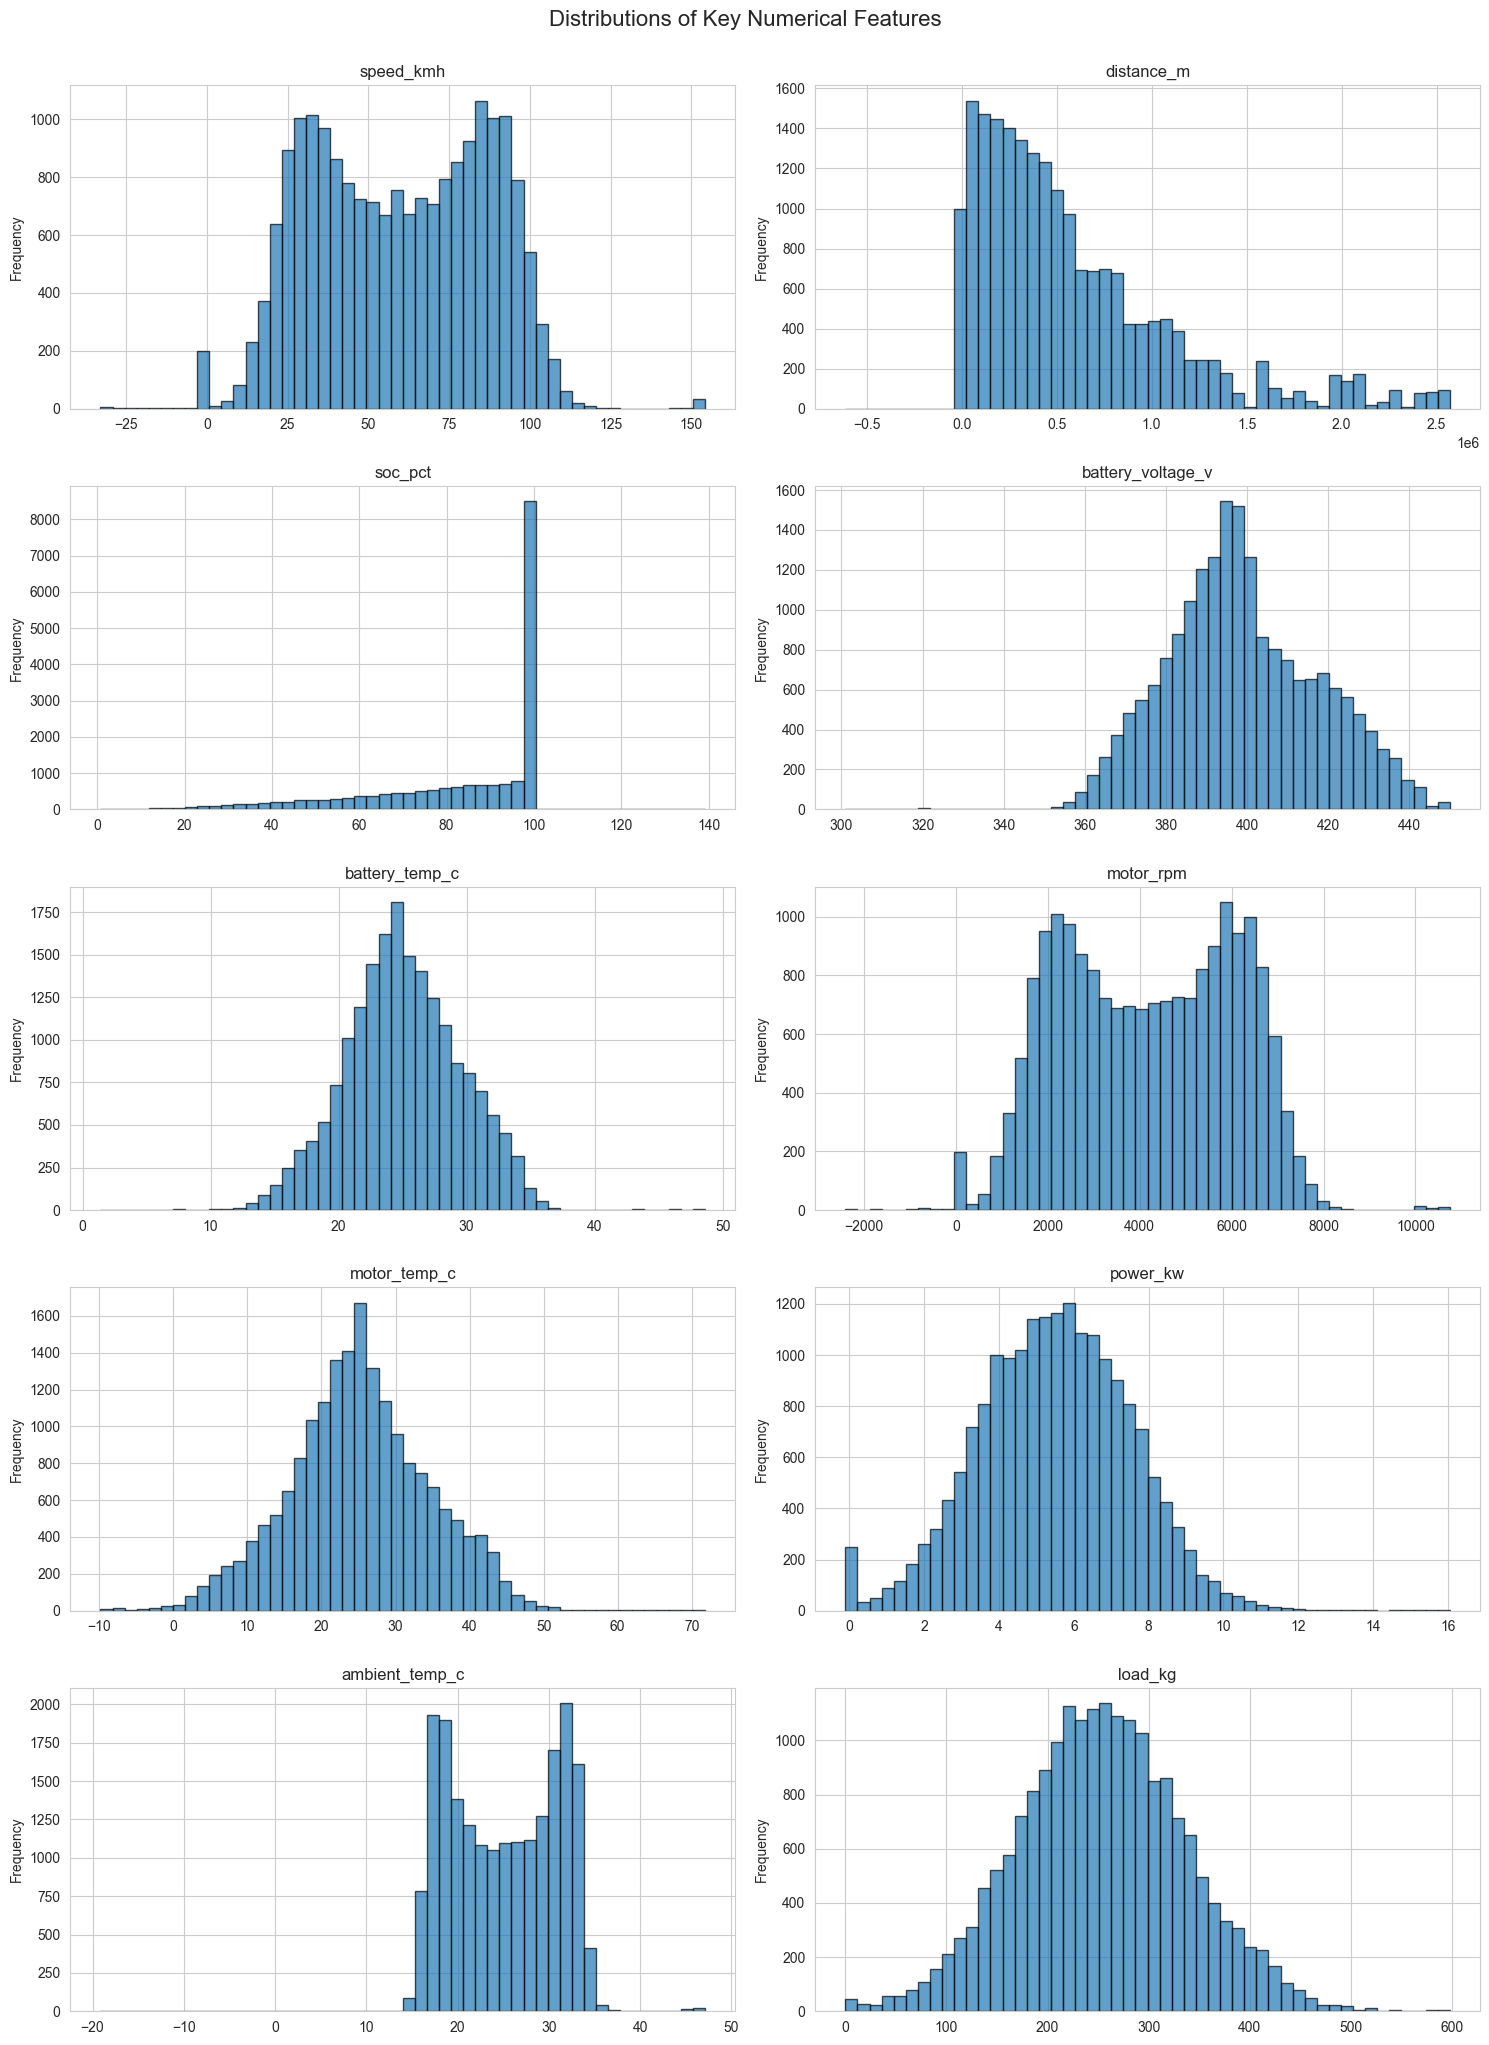

In [21]:
import matplotlib.pyplot as plt

features_to_plot = [
    'speed_kmh',
    'distance_m',
    'soc_pct',
    'battery_voltage_v',
    'battery_temp_c',
    'motor_rpm',
    'motor_temp_c',
    'power_kw',
    'ambient_temp_c',
    'load_kg'
]

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    ax = axes[i]
    df[col].hist(bins=50, edgecolor='black', alpha=0.7, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.suptitle("Distributions of Key Numerical Features", fontsize=16, y=1.02)

# plt.savefig("../output/distribution_histograms_for_Specific_Features.png", dpi=300)

plt.show()

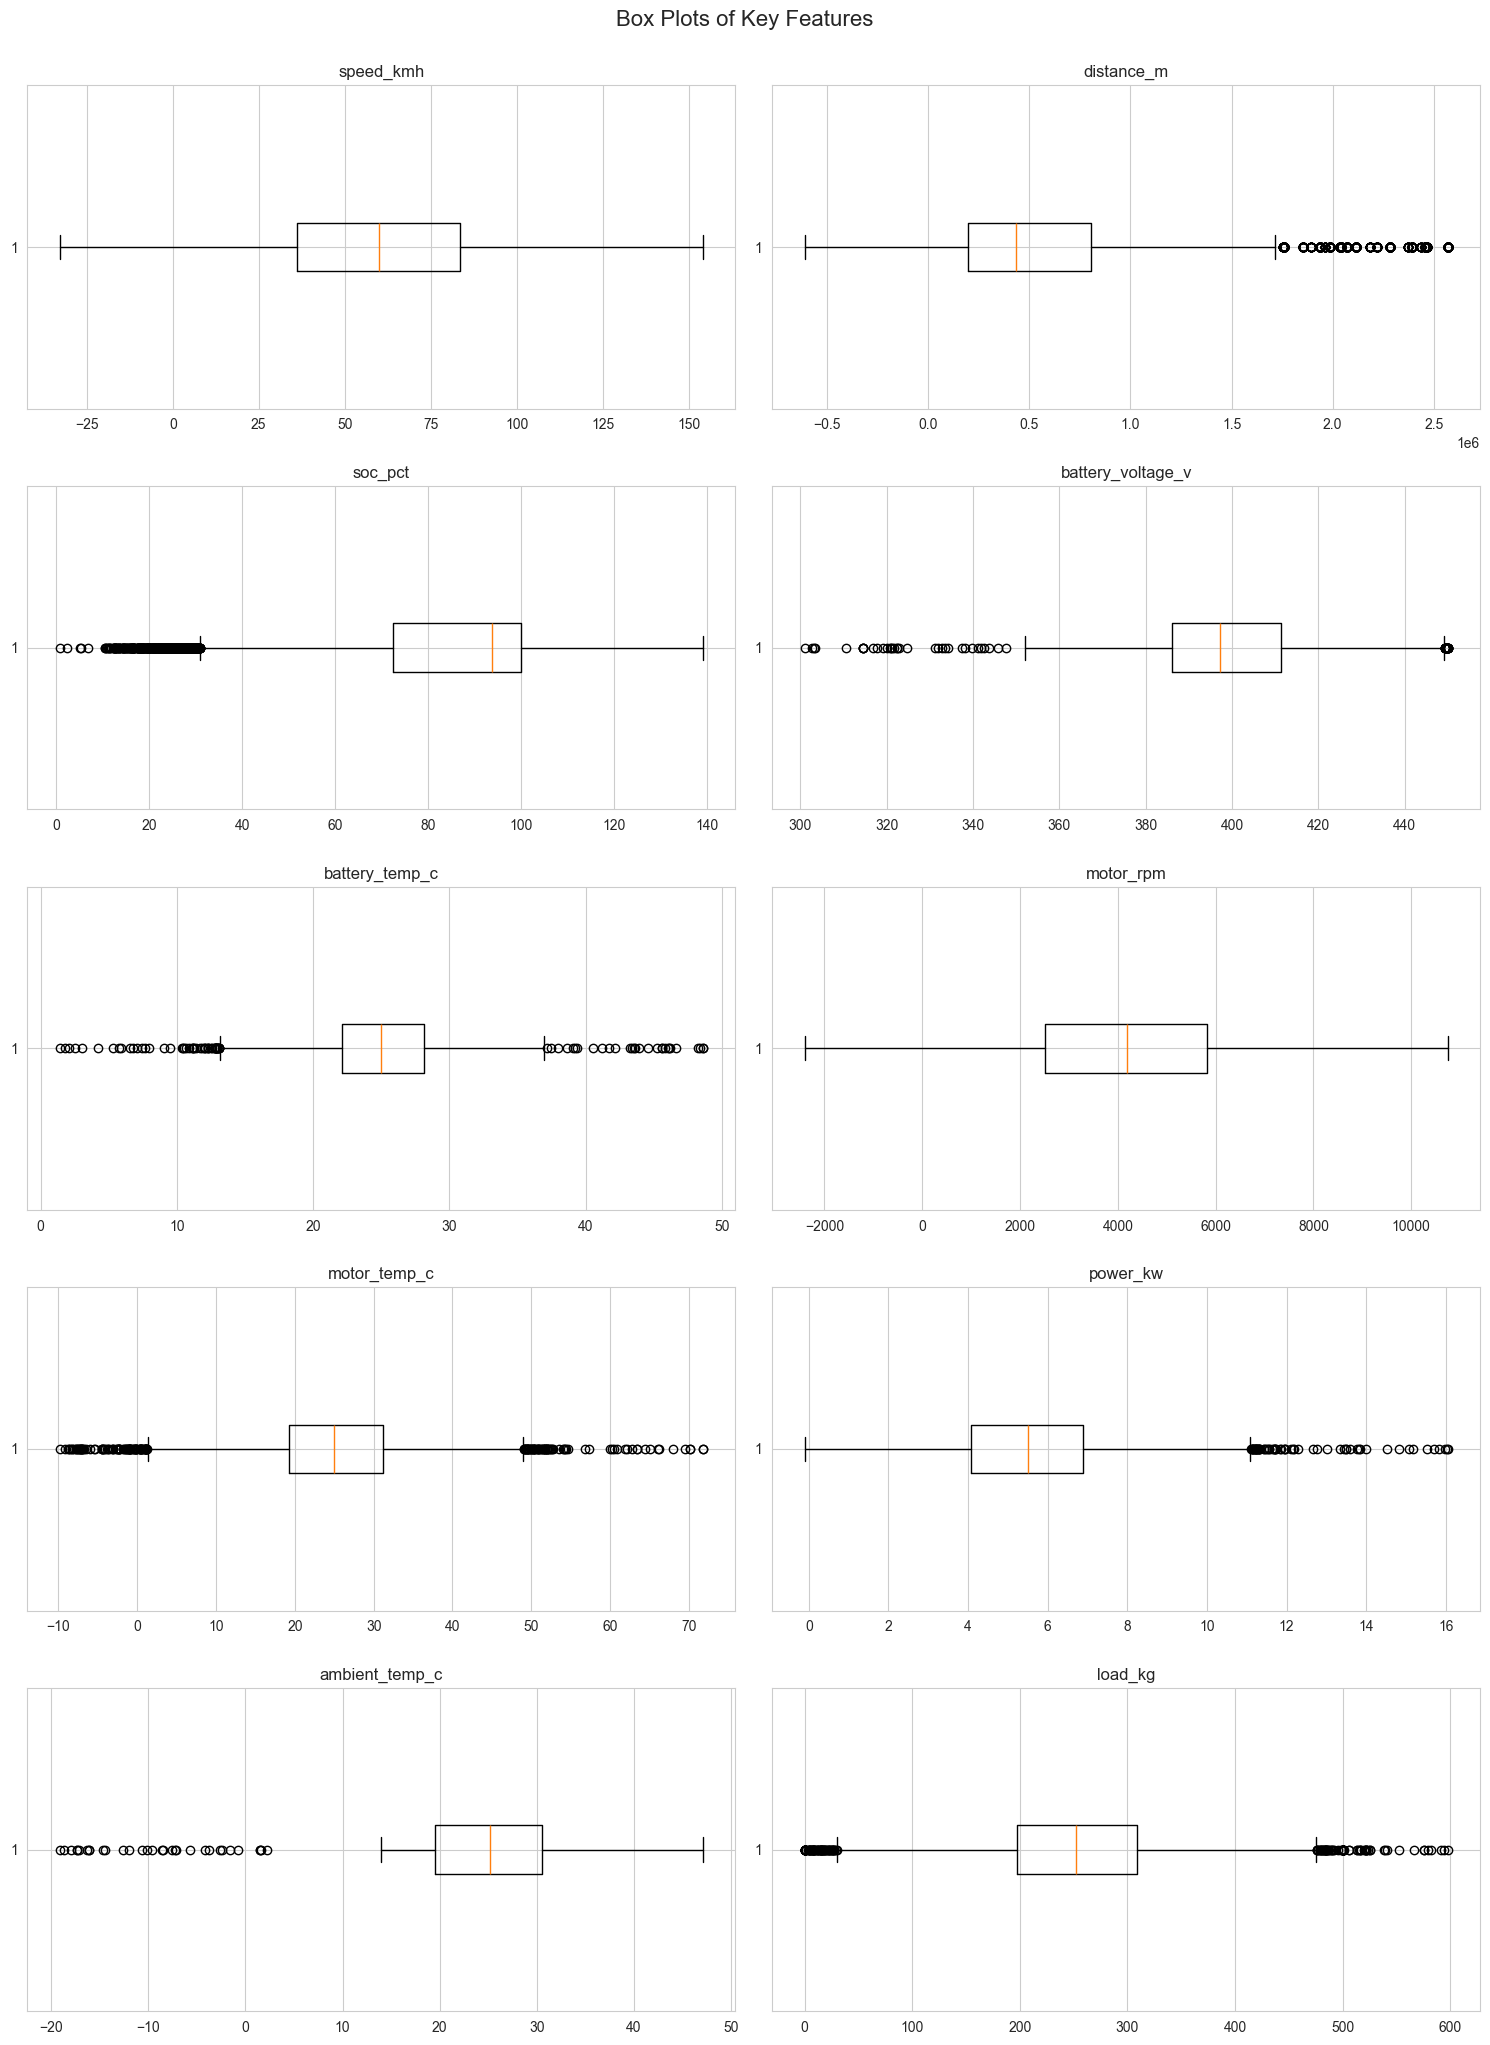

In [23]:
import math
import matplotlib.pyplot as plt

features_to_plot = [
    'speed_kmh',
    'distance_m',
    'soc_pct',
    'battery_voltage_v',
    'battery_temp_c',
    'motor_rpm',
    'motor_temp_c',
    'power_kw',
    'ambient_temp_c',
    'load_kg'
]

n_cols = 2
n_rows = math.ceil(len(features_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    axes[i].boxplot(df[col].dropna(), vert=False)
    axes[i].set_title(col)

# Remove unused axes
for j in range(len(features_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Box Plots of Key Features', fontsize=16, y=1.02)

# plt.savefig('../output/box_plots_for_Specific_Features.png', dpi=300)

plt.show()

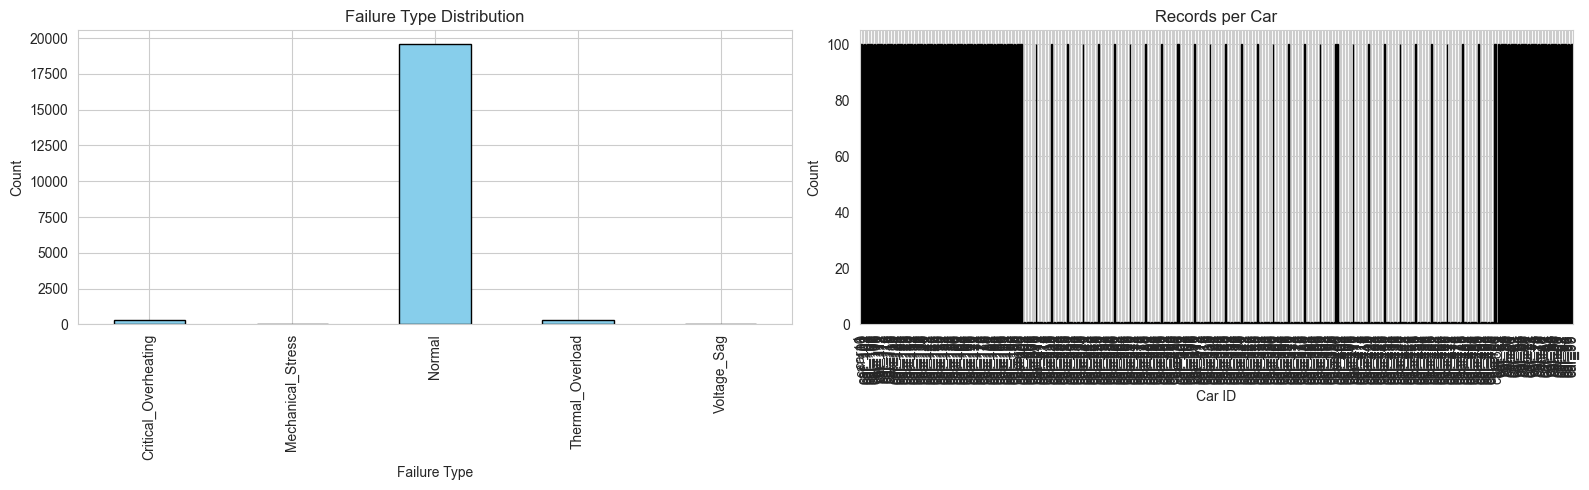

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Failure type distribution
df['failure_type'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[0],
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Failure Type Distribution')
axes[0].set_xlabel('Failure Type')
axes[0].set_ylabel('Count')

# Number of records per car
df['car_id'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[1],
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Records per Car')
axes[1].set_xlabel('Car ID')
axes[1].set_ylabel('Count')

plt.tight_layout()

# plt.savefig('../output/categorical_distribution.png', dpi=300)

plt.show()

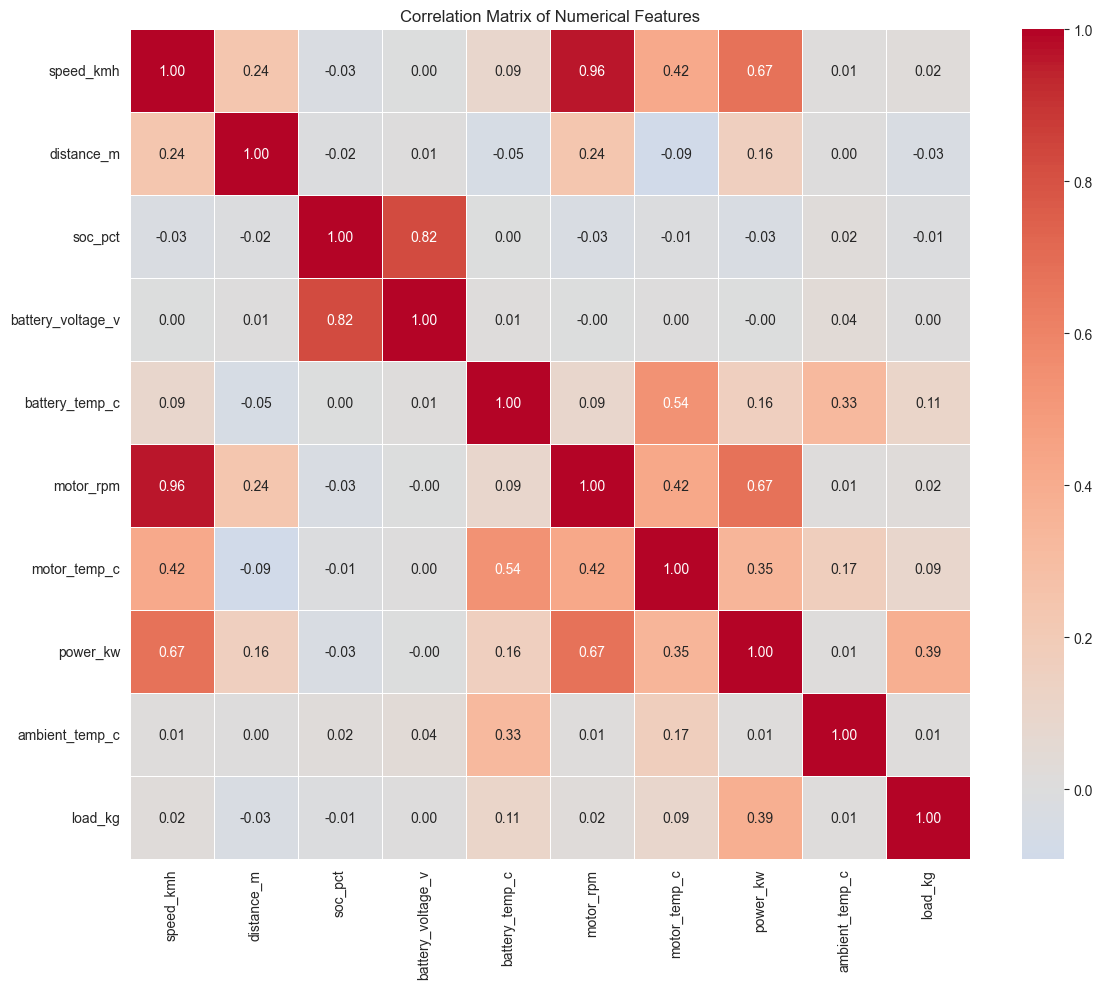

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

corr_matrix = df.drop(
    columns=['timestamp', 'car_id', 'failure_type'],
    errors='ignore'
).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()

# plt.savefig('../output/correlation_matrix.png', dpi=300)

plt.show()

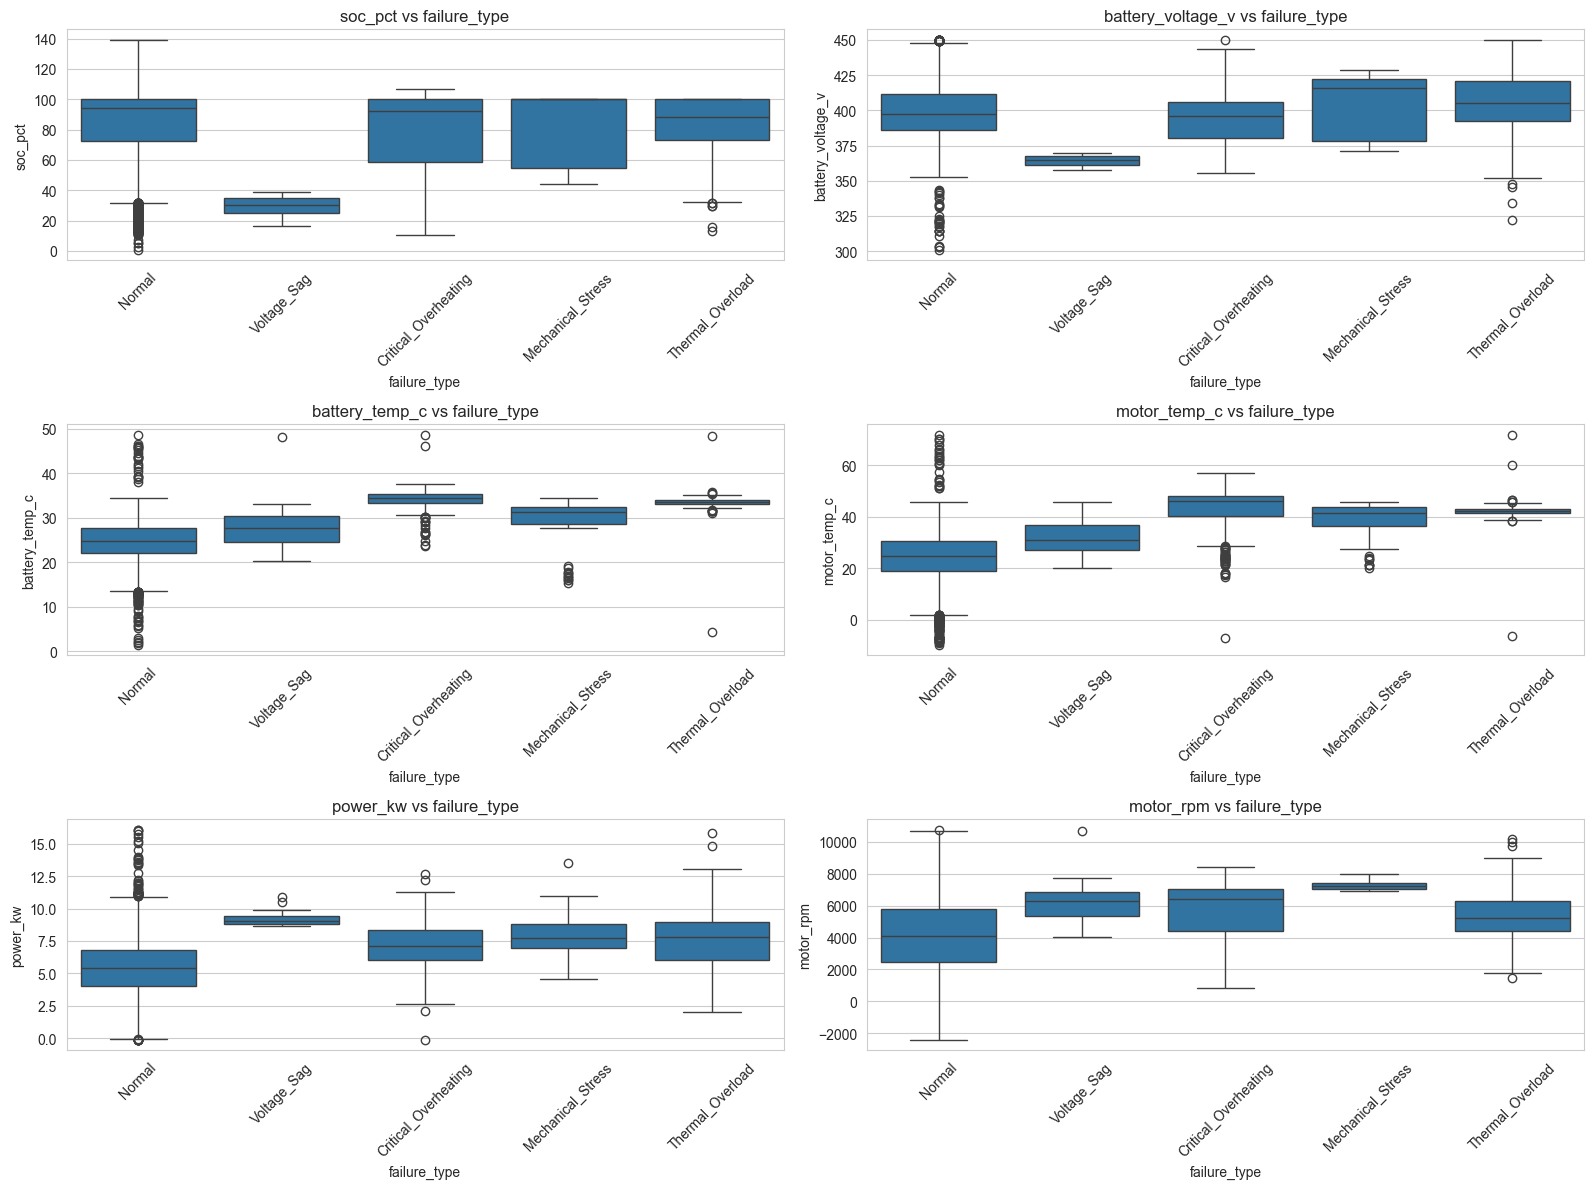

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = 'failure_type'

related_cols = [
    'soc_pct',
    'battery_voltage_v',
    'battery_temp_c',
    'motor_temp_c',
    'power_kw',
    'motor_rpm'
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(related_cols):
    sns.boxplot(
        data=df,
        x=target_col,
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs {target_col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()

# plt.savefig('../output/bivariate_relationships.png', dpi=300)

plt.show()

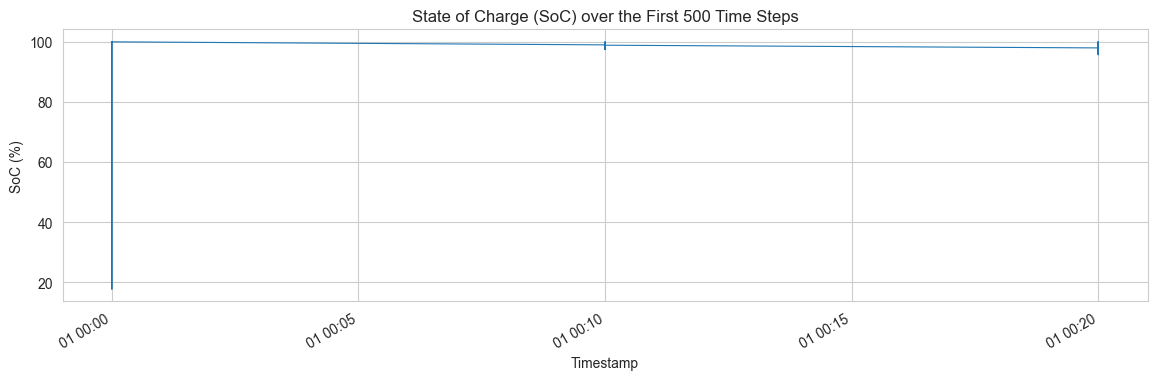

In [28]:
import matplotlib.pyplot as plt

# Sort by timestamp
df_sorted = df.sort_values('timestamp')

# Plot the first 500 records
plt.figure(figsize=(14, 4))

df_sorted.set_index('timestamp')['soc_pct'].head(500).plot(linewidth=0.8)

plt.title('State of Charge (SoC) over the First 500 Time Steps')
plt.ylabel('SoC (%)')
plt.xlabel('Timestamp')

# plt.savefig('../output/soc_time_series.png', dpi=300)

plt.show()

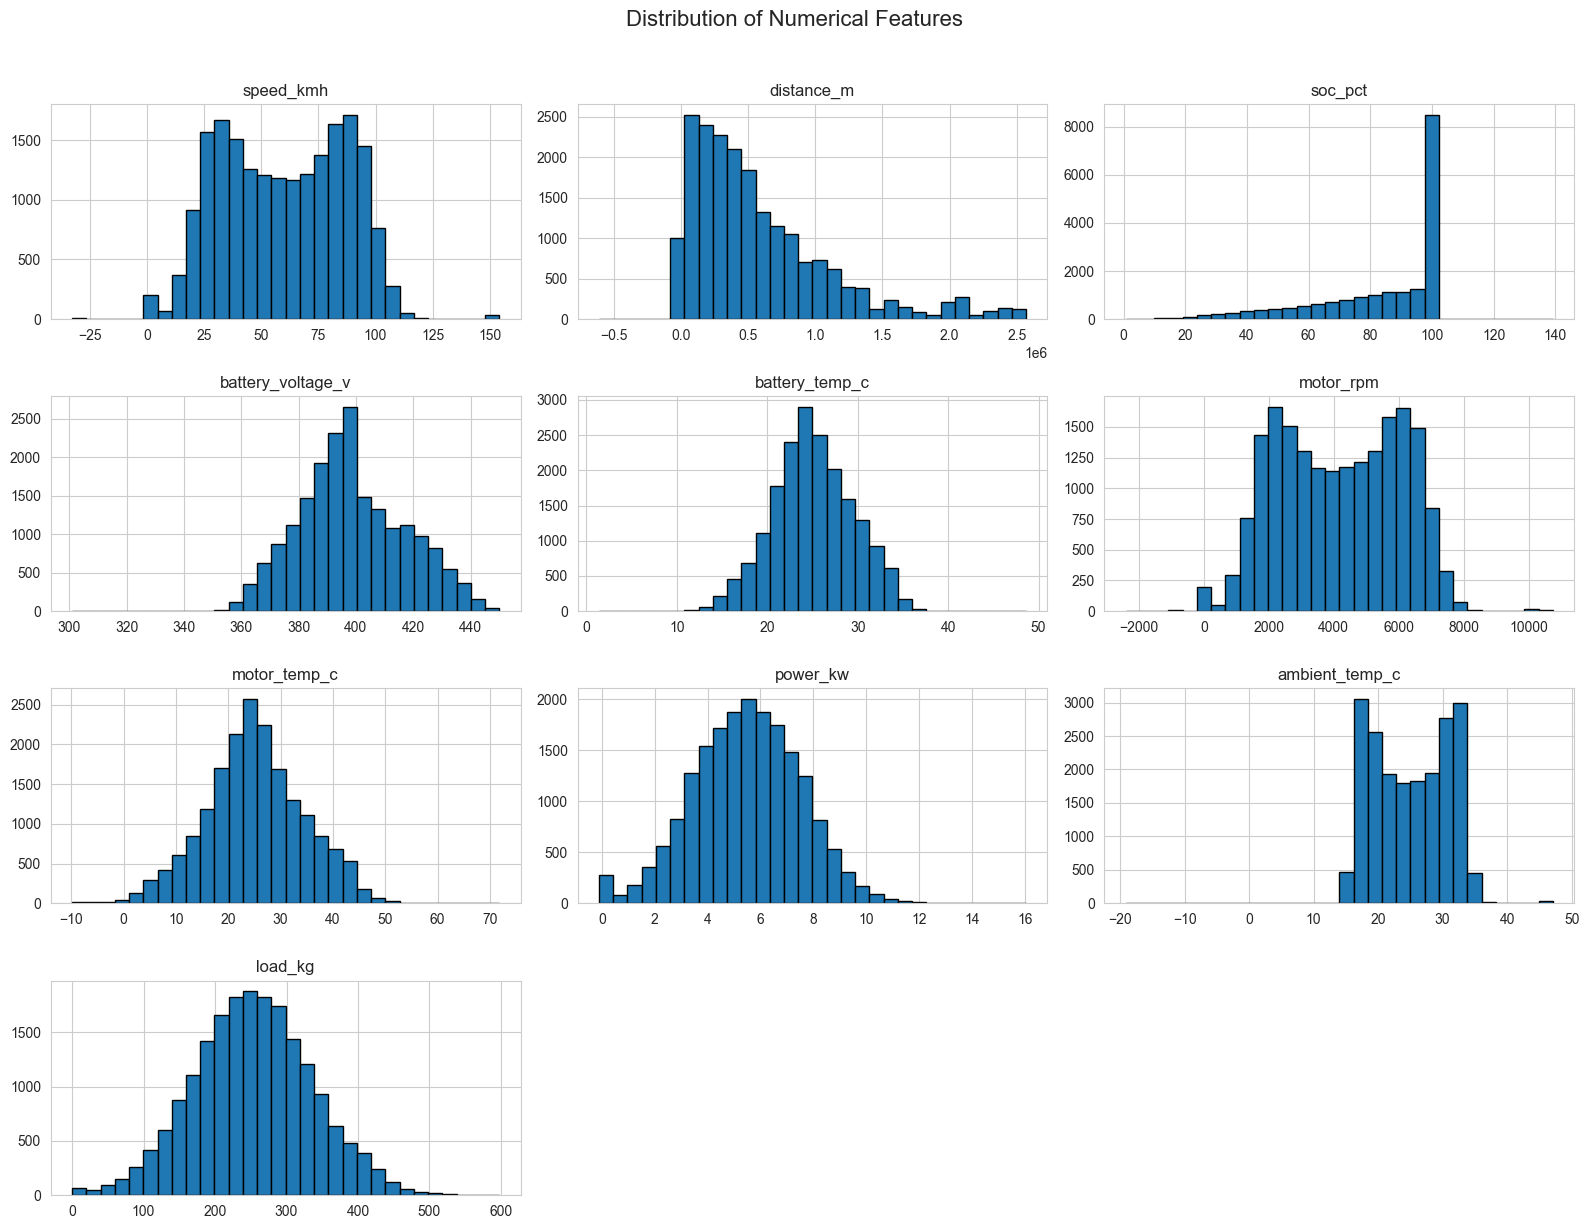

In [29]:
import matplotlib.pyplot as plt

# Select only numerical columns
numeric_df = df.select_dtypes(include=['number'])

numeric_df.hist(
    figsize=(16, 12),
    bins=30,
    edgecolor='black'
)

plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()

# plt.savefig('../output/distribution_histograms.png', dpi=300)

plt.show()

In [32]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd

# Copy the dataframe
data = df.copy()

# Encode categorical target
le = LabelEncoder()
data['failure_type'] = le.fit_transform(data['failure_type'])

# Encode car_id since it's categorical
data['car_id'] = LabelEncoder().fit_transform(data['car_id'])

# Features and target
X = data.drop(columns=['timestamp', 'failure_type'])
y = data['failure_type']

# Compute Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)

mi_series = pd.Series(mi_scores, index=X.columns).sort_values()

# Plot
plt.figure(figsize=(10, 6))

mi_series.plot(
    kind='barh',
    color='skyblue',
    edgecolor='black'
)

plt.title('Mutual Information Scores')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# plt.savefig('../output/mutual_info_plot.png', dpi=300)

plt.show()

ValueError: Input X contains NaN.

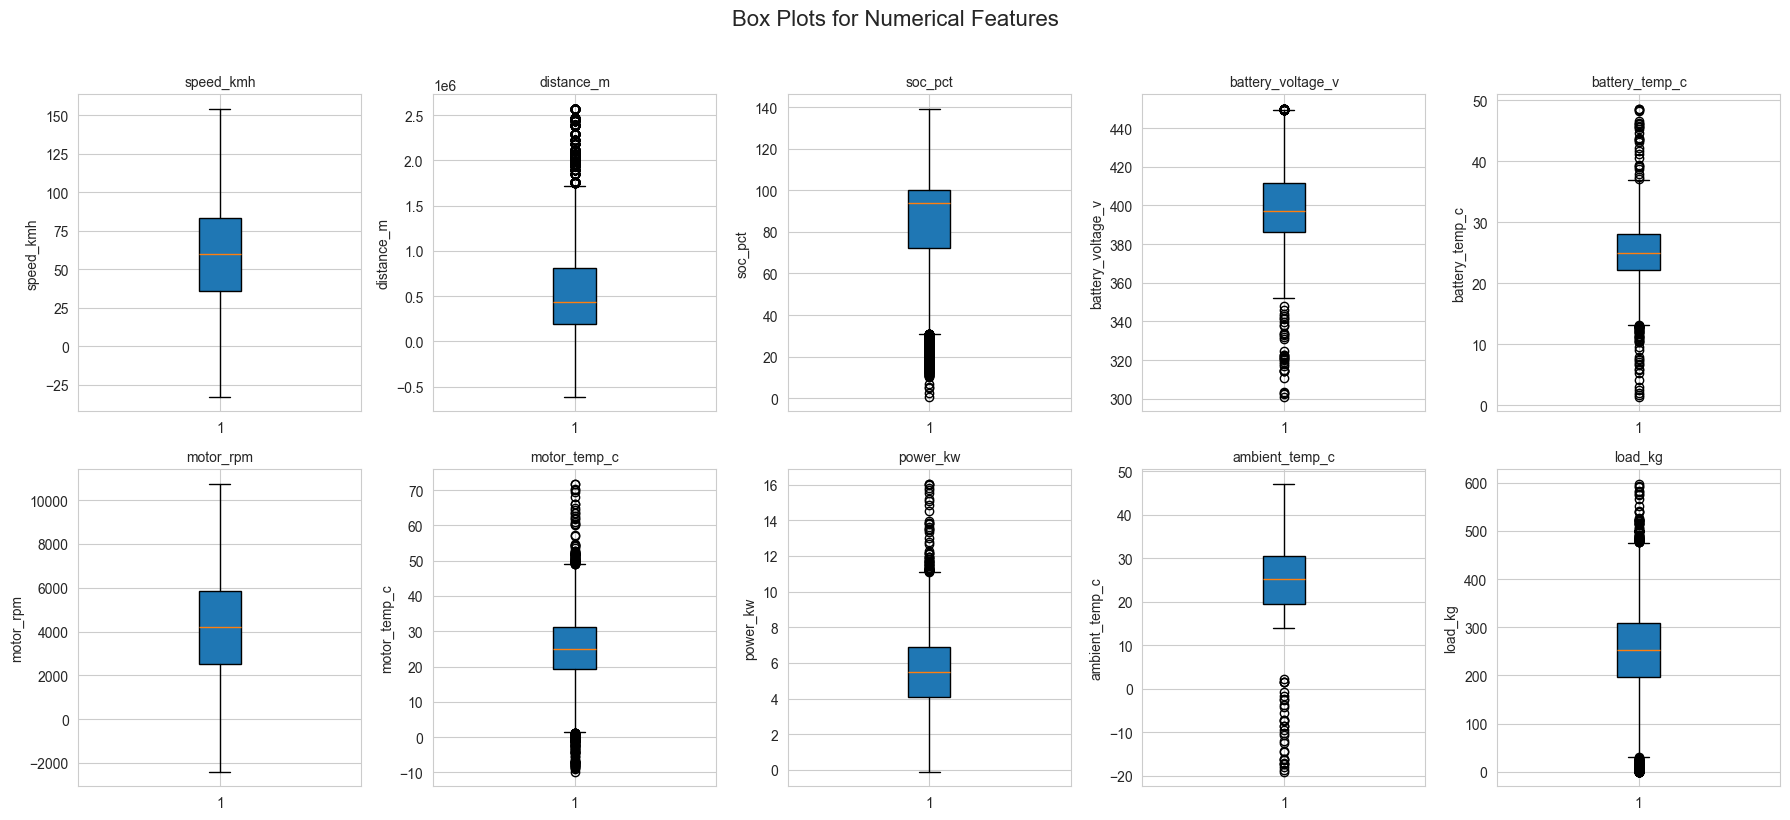

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Select numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = 5
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(18, 4 * n_rows)
)

axes = np.array(axes).flatten()

for ax, col in zip(axes, numerical_cols):
    ax.boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True
    )
    ax.set_title(col, fontsize=10)
    ax.set_ylabel(col)

# Hide unused axes
for ax in axes[len(numerical_cols):]:
    ax.set_visible(False)

plt.suptitle("Box Plots for Numerical Features", fontsize=16, y=1.02)
plt.tight_layout()

# plt.savefig("../output/box_plots.png", dpi=300)

plt.show()

**Initial Insights & Hypotheses:**
1. **Relationships** No linear relation between features and target variable, but there are some non-linear relationships.
2. **Motor_Vibration** is the most important feature for predicting Failure_Probability.
3. **SoH tends to decrease with increasing Charge_Cycles**, as expected from battery degradation.
4. **RUL is positively correlated with SoH and Component_Health_Score**, and negatively correlated with Charge_Cycles.
5. **Battery_Current** shows extreme values that might indicate fast charging/discharging events.
6. **Maintenance_Type** appears somewhat related to Failure_Probability; types 1-3 may be associated with different failure modes.
7. **Some features exhibit seasonal-like variation** (e.g., battery temperature), likely due to ambient conditions or driving patterns.
8. **Hypothesis**: The combination of SoH, Charge_Cycles, Motor_Temperature, and Battery_Temperature could be strong predictors of RUL.

---
### Task 4: Verify Data Quality

Check for missing values, duplicates, outliers, and inconsistencies.

In [34]:
# Missing values check
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
if len(missing_report) == 0:
    print("No missing values detected in any column.")
else:
    print("=== Missing Values Report ===")
    print(missing_report)

=== Missing Values Report ===
                   Missing Count  Missing %
motor_temp_c                1634     8.0493
battery_temp_c              1475     7.2660
power_kw                    1239     6.1034
soc_pct                     1185     5.8374
motor_rpm                   1061     5.2266
battery_voltage_v            884     4.3547
load_kg                      762     3.7537
speed_kmh                    640     3.1527
ambient_temp_c               422     2.0788
distance_m                   217     1.0690


In [35]:
# Duplicate records
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [36]:
# Outlier detection using Z-score for ALL numerical columns
num_cols = df.select_dtypes(include=np.number).columns
outlier_summary = []

for col in num_cols:
    # Drop NaN just in case (though none exist)
    col_data = df[col].dropna()
    # Calculate Z-scores (ignoring any potential inf from constant columns)
    z = np.abs(stats.zscore(col_data))
    outlier_count = (z > 3).sum()
    outlier_pct = (outlier_count / len(col_data)) * 100
    outlier_summary.append([col, outlier_count, outlier_pct])

outlier_df = pd.DataFrame(outlier_summary, columns=['Column', 'Outlier Count', 'Outlier %'])
outlier_df = outlier_df.sort_values('Outlier %', ascending=False)
print(outlier_df.to_string(index=False))

           Column  Outlier Count  Outlier %
       distance_m            414     2.0614
          soc_pct            147     0.7690
   ambient_temp_c             68     0.3421
     motor_temp_c             62     0.3322
   battery_temp_c             53     0.2815
          load_kg             54     0.2764
        speed_kmh             49     0.2492
        motor_rpm             39     0.2027
         power_kw             36     0.1889
battery_voltage_v             32     0.1648


In [38]:
# Data type consistency
print("Data types:")
print(df.dtypes)

# Columns that should never be negative
non_neg_cols = [
    'speed_kmh',
    'distance_m',
    'soc_pct',
    'battery_voltage_v',
    'motor_rpm',
    'load_kg'
]

neg_counts = {
    col: (df[col] < 0).sum()
    for col in non_neg_cols
    if col in df.columns
}

neg_report = {
    col: cnt
    for col, cnt in neg_counts.items()
    if cnt > 0
}

if neg_report:
    print("\nColumns with unexpected negative values:")
    print(neg_report)
else:
    print("\n✅ No unexpected negative values in constrained columns.")

Data types:
timestamp            datetime64[us]
speed_kmh                   float64
distance_m                  float64
soc_pct                     float64
battery_voltage_v           float64
battery_temp_c              float64
motor_rpm                   float64
motor_temp_c                float64
power_kw                    float64
ambient_temp_c              float64
load_kg                     float64
car_id                          str
failure_type                    str
dtype: object

Columns with unexpected negative values:
{'speed_kmh': np.int64(26), 'distance_m': np.int64(1), 'motor_rpm': np.int64(25)}


**Data Quality Summary**
The dataset contains missing values in several numerical features, including soc_pct, battery_voltage_v, battery_temp_c, motor_rpm, motor_temp_c, power_kw, speed_kmh, distance_m, ambient_temp_c, and load_kg. These missing values should be handled before model training using an appropriate imputation strategy.
No duplicate rows were detected.
Several numerical features exhibit potential outliers, particularly speed_kmh, motor_rpm, power_kw, battery_voltage_v, battery_temp_c, and motor_temp_c. These values may correspond to realistic operating conditions rather than data errors, so they should be investigated before deciding whether to remove or retain them.
Data types are appropriate for analysis: timestamp is stored as a datetime field, numerical measurements are stored as floating-point values, and car_id and failure_type are stored as categorical/string variables.
The dataset contains time-series observations identified by the timestamp column. If temporal analysis is required, the data should be sorted by timestamp, and the regularity of the sampling intervals should be verified before time-series modeling.
Overall, the dataset is structurally consistent and suitable for exploratory data analysis and predictive maintenance modeling after addressing the missing values and evaluating the detected outliers.